# Breast Cancer Diagnosis (Classification)





#Importing Libraries 

In [1]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Breast_Cancer_Prediction.csv")
df

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
678,776715,3,1,1,1,3,2,1,1,1,2
679,841769,2,1,1,1,2,1,1,1,1,2
680,888820,5,10,10,3,7,3,8,10,2,4
681,897471,4,8,6,4,3,4,10,6,1,4


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Sample code number           683 non-null    int64
 1   Clump Thickness              683 non-null    int64
 2   Uniformity of Cell Size      683 non-null    int64
 3   Uniformity of Cell Shape     683 non-null    int64
 4   Marginal Adhesion            683 non-null    int64
 5   Single Epithelial Cell Size  683 non-null    int64
 6   Bare Nuclei                  683 non-null    int64
 7   Bland Chromatin              683 non-null    int64
 8   Normal Nucleoli              683 non-null    int64
 9   Mitoses                      683 non-null    int64
 10  Class                        683 non-null    int64
dtypes: int64(11)
memory usage: 58.8 KB


In [3]:
df.columns = df.columns.str.replace(' ', '_')

In [4]:
# عدد الصفوف المكررة
print("Duplicates:", df.duplicated().sum())

# حذف التكرار
df = df.drop_duplicates()

# التأكد
print("New Shape:", df.shape)

Duplicates: 8
New Shape: (675, 11)


In [5]:
df = df.drop(columns = 'Sample_code_number')


In [6]:
for i in df.columns:
    print({i},df[i].unique())

{'Clump_Thickness'} [ 5  3  6  4  8  1  2  7 10  9]
{'Uniformity_of_Cell_Size'} [ 1  4  8 10  2  3  7  5  6  9]
{'Uniformity_of_Cell_Shape'} [ 1  4  8 10  2  3  5  6  7  9]
{'Marginal_Adhesion'} [ 1  5  3  8 10  4  6  2  9  7]
{'Single_Epithelial_Cell_Size'} [ 2  7  3  1  6  4  5  8 10  9]
{'Bare_Nuclei'} [ 1 10  2  4  3  9  7  5  8  6]
{'Bland_Chromatin'} [ 3  9  1  2  4  5  7  8  6 10]
{'Normal_Nucleoli'} [ 1  2  7  4  5  3 10  6  9  8]
{'Mitoses'} [ 1  5  4  2  3  7 10  8  6]
{'Class'} [2 4]


#Data Representation





In [7]:
df.isna().all()


Clump_Thickness                False
Uniformity_of_Cell_Size        False
Uniformity_of_Cell_Shape       False
Marginal_Adhesion              False
Single_Epithelial_Cell_Size    False
Bare_Nuclei                    False
Bland_Chromatin                False
Normal_Nucleoli                False
Mitoses                        False
Class                          False
dtype: bool

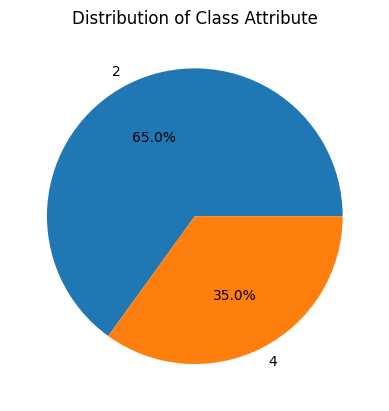

In [8]:


# Plot a pie chart of the class attribute
plt.pie(df['Class'].value_counts(), labels=df['Class'].unique(), autopct='%1.1f%%')
plt.title('Distribution of Class Attribute')
plt.show()



C:\Users\shahed\AppData\Local\Temp\ipykernel_17284\1997120903.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Clump_Thickness'], ax = ax[0,0], color = 'red')
C:\Users\shahed\AppData\Local\Temp\ipykernel_17284\1997120903.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Uniformity_o

<Axes: xlabel='Class', ylabel='Density'>

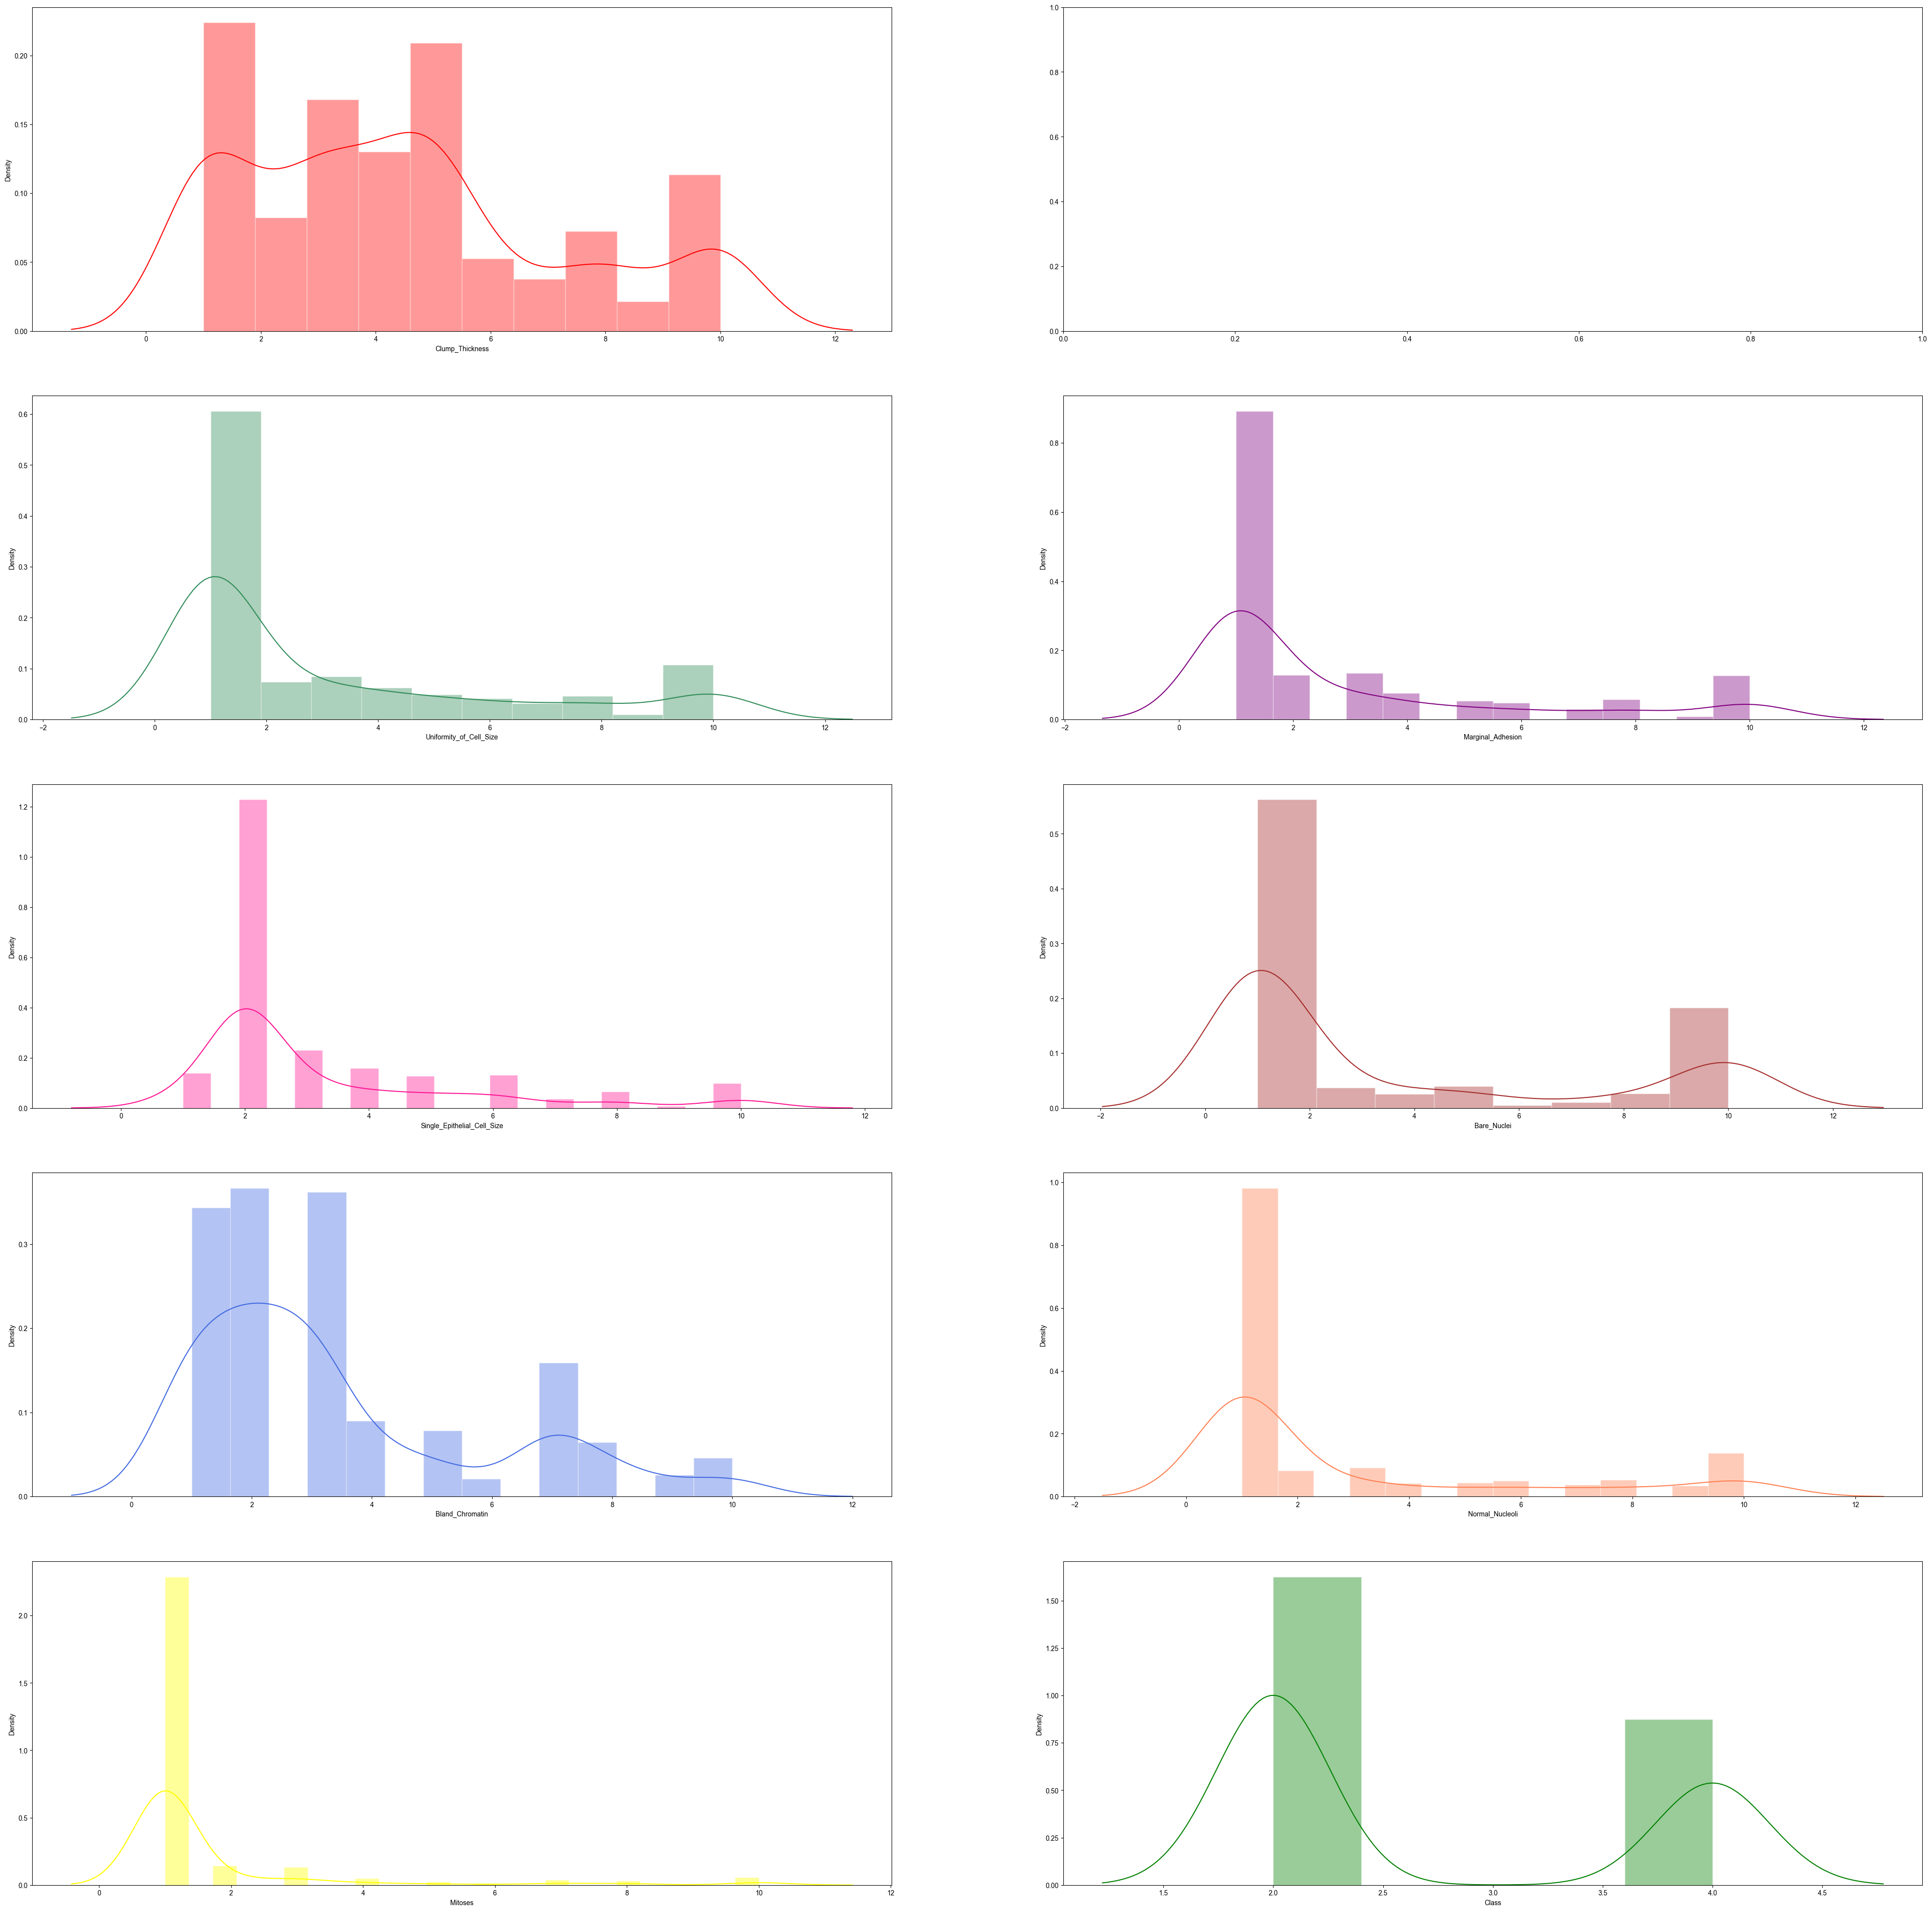

In [9]:

fig, ax = plt.subplots(5,2, figsize=(50,50))
sns.set(font_scale = 3)
sns.distplot(df['Clump_Thickness'], ax = ax[0,0], color = 'red')
sns.distplot(df['Uniformity_of_Cell_Size'], ax = ax[1,0], color = 'seagreen')
sns.distplot(df['Marginal_Adhesion'], ax = ax[1,1], color = 'purple')
sns.distplot(df['Single_Epithelial_Cell_Size'], ax = ax[2,0], color = 'deeppink')
sns.distplot(df['Bare_Nuclei'], ax = ax[2,1], color = 'brown')
sns.distplot(df['Bland_Chromatin'], ax = ax[3,0], color = 'royalblue')
sns.distplot(df['Normal_Nucleoli'], ax = ax[3,1], color = 'coral')
sns.distplot(df['Mitoses'], ax = ax[4,0], color = 'yellow')
sns.distplot(df['Class'], ax = ax[4,1], color = 'green')

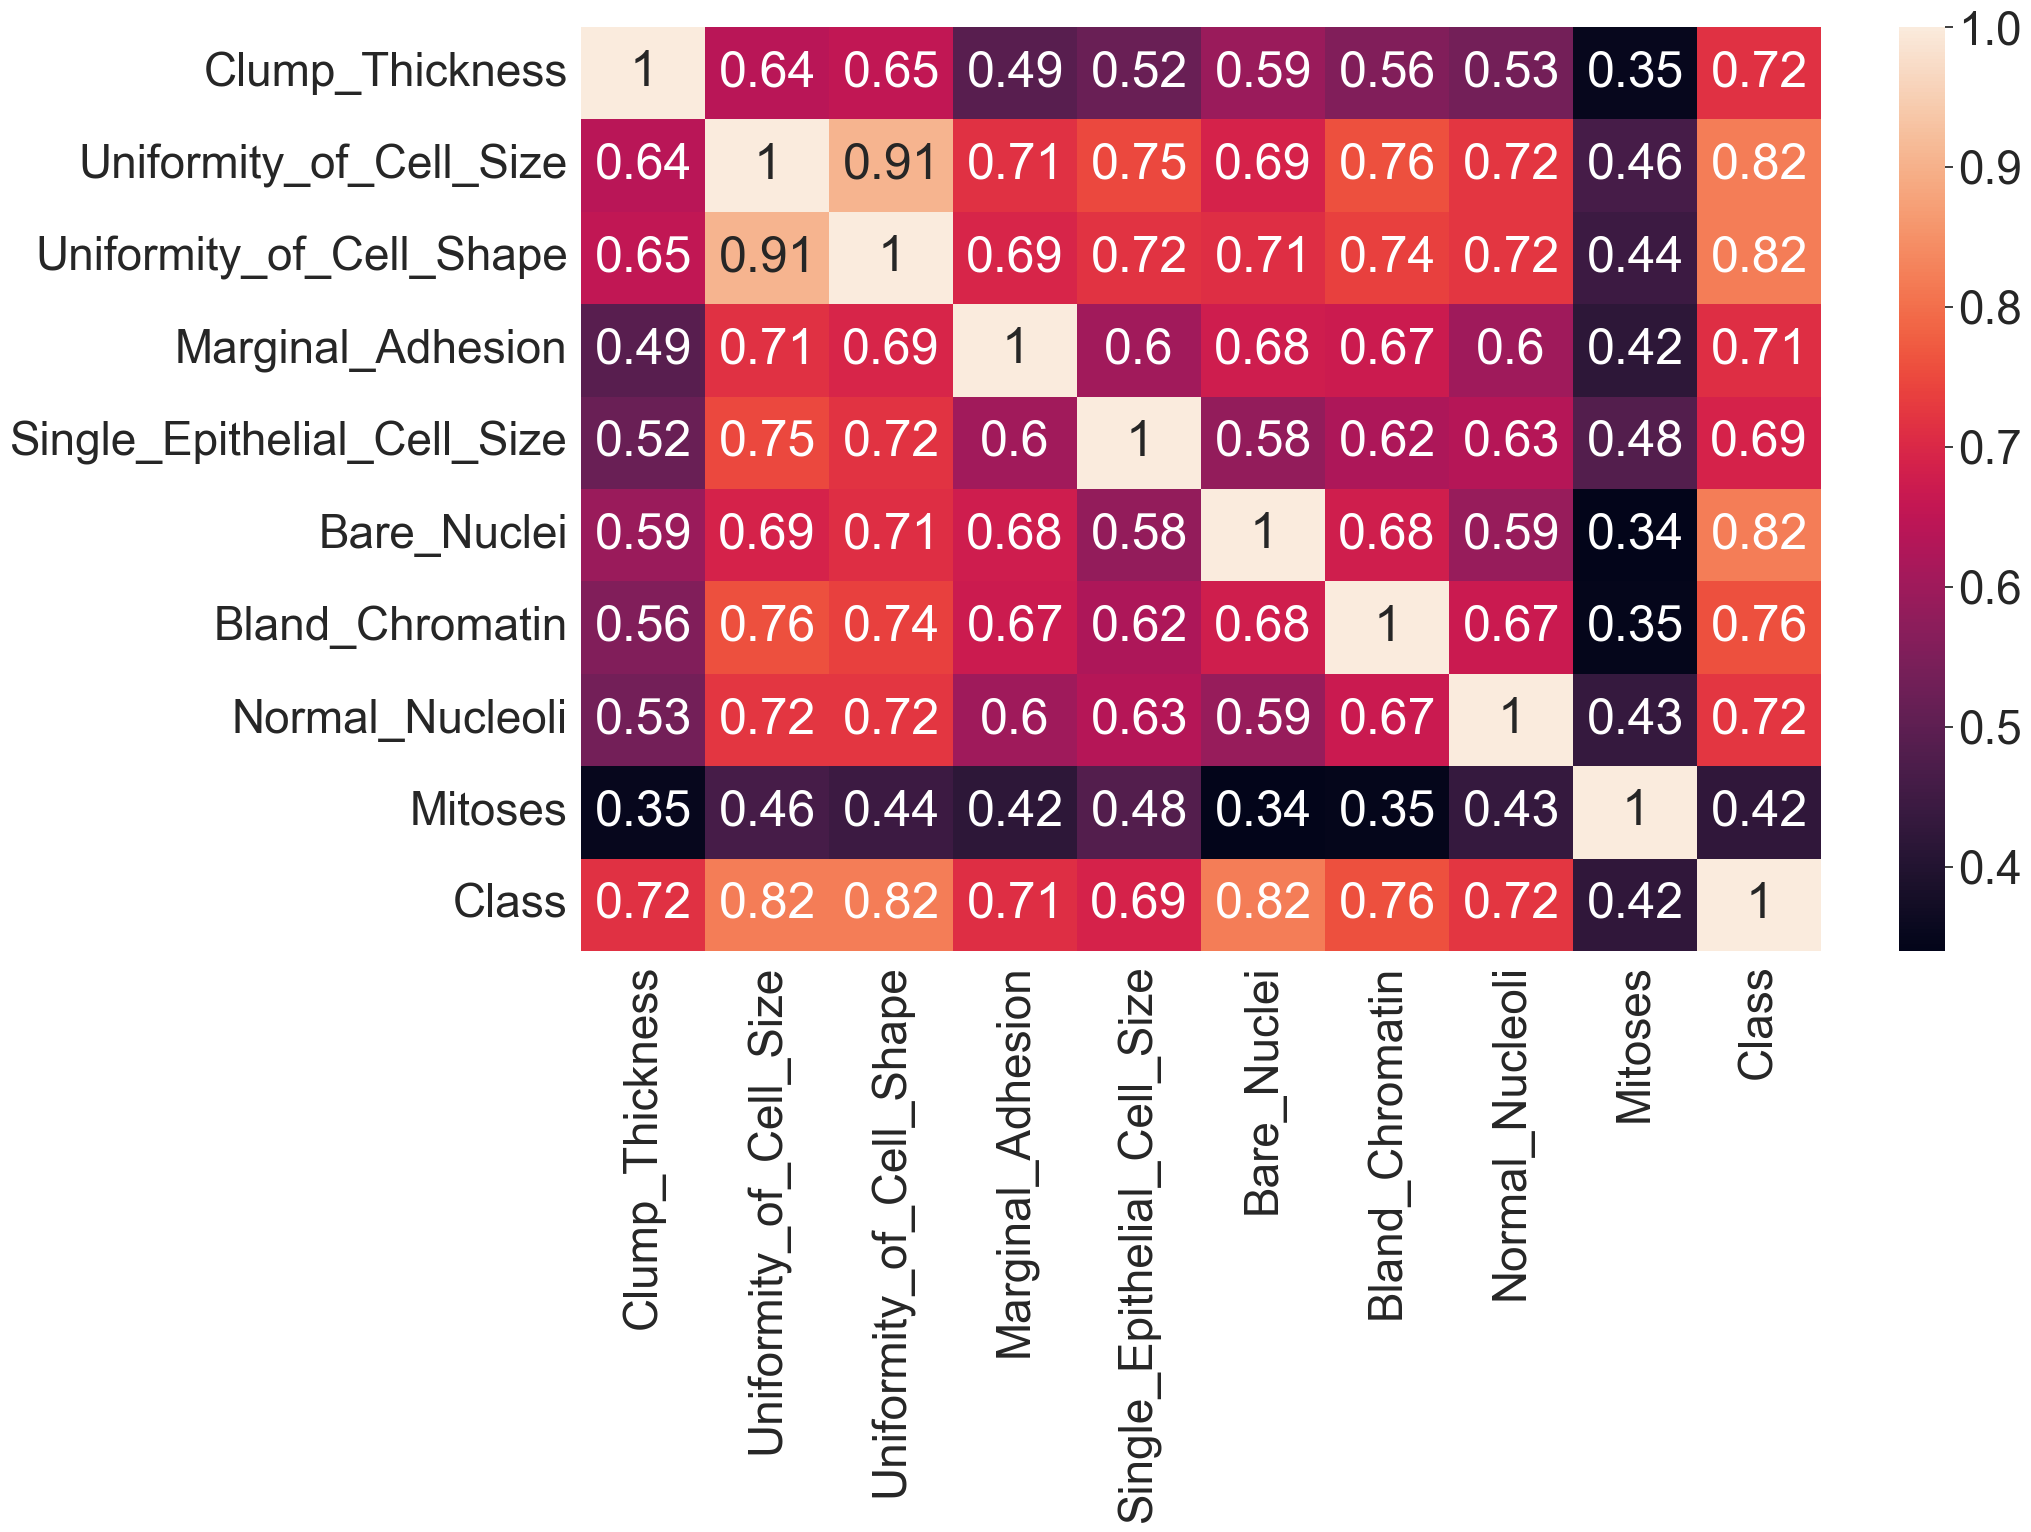

In [10]:
# Heat Map
corr_df = df.corr()
plt.figure(figsize = (20, 12))
sns.heatmap(data = corr_df, annot = True)
plt.show()

In [11]:
# حذف أحد العمودين المتكررين للاختزال (Dimensionality Reduction)
# سنقوم بحذف Uniformity_of_Cell_Shape ونبقي على Uniformity_of_Cell_Size
df = df.drop(columns=['Uniformity_of_Cell_Shape'])


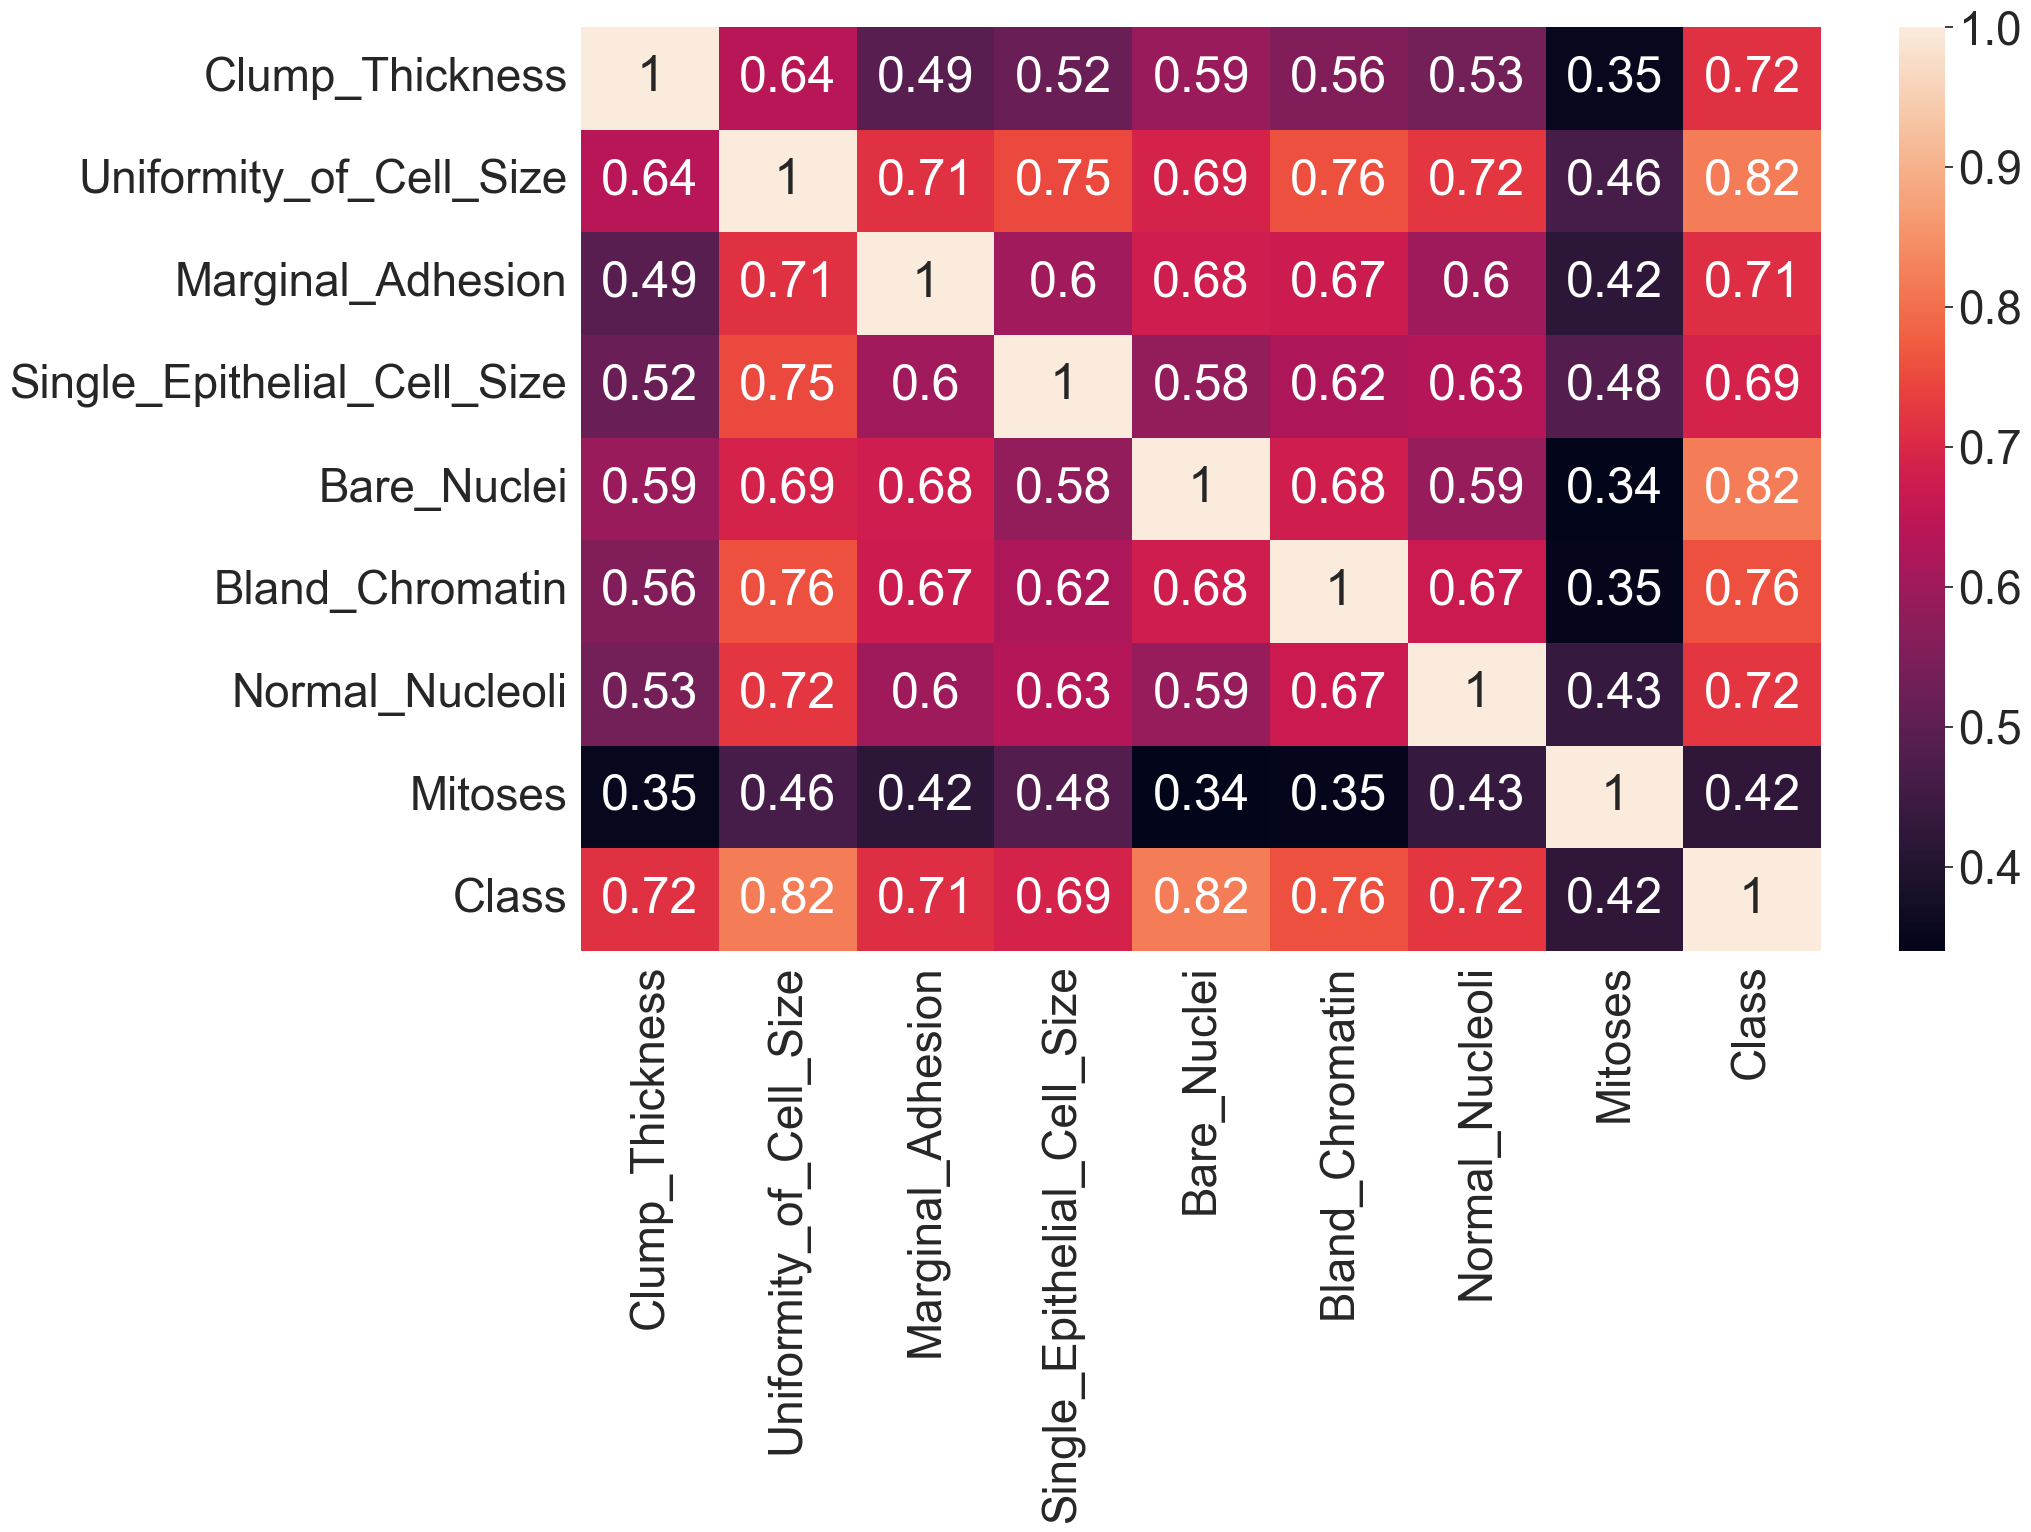

In [12]:
# Heat Map
corr_df = df.corr()
plt.figure(figsize = (20, 12))
sns.heatmap(data = corr_df, annot = True)
plt.show()

In [13]:
df = df.drop(columns=['Uniformity_of_Cell_Size'])
df = df.drop(columns=['Bare_Nuclei'])
df.columns

Index(['Clump_Thickness', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size',
       'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class'],
      dtype='str')

Generating Pair Plot...
Generating Boxplots...
Generating Histograms...
All plots generated successfully.


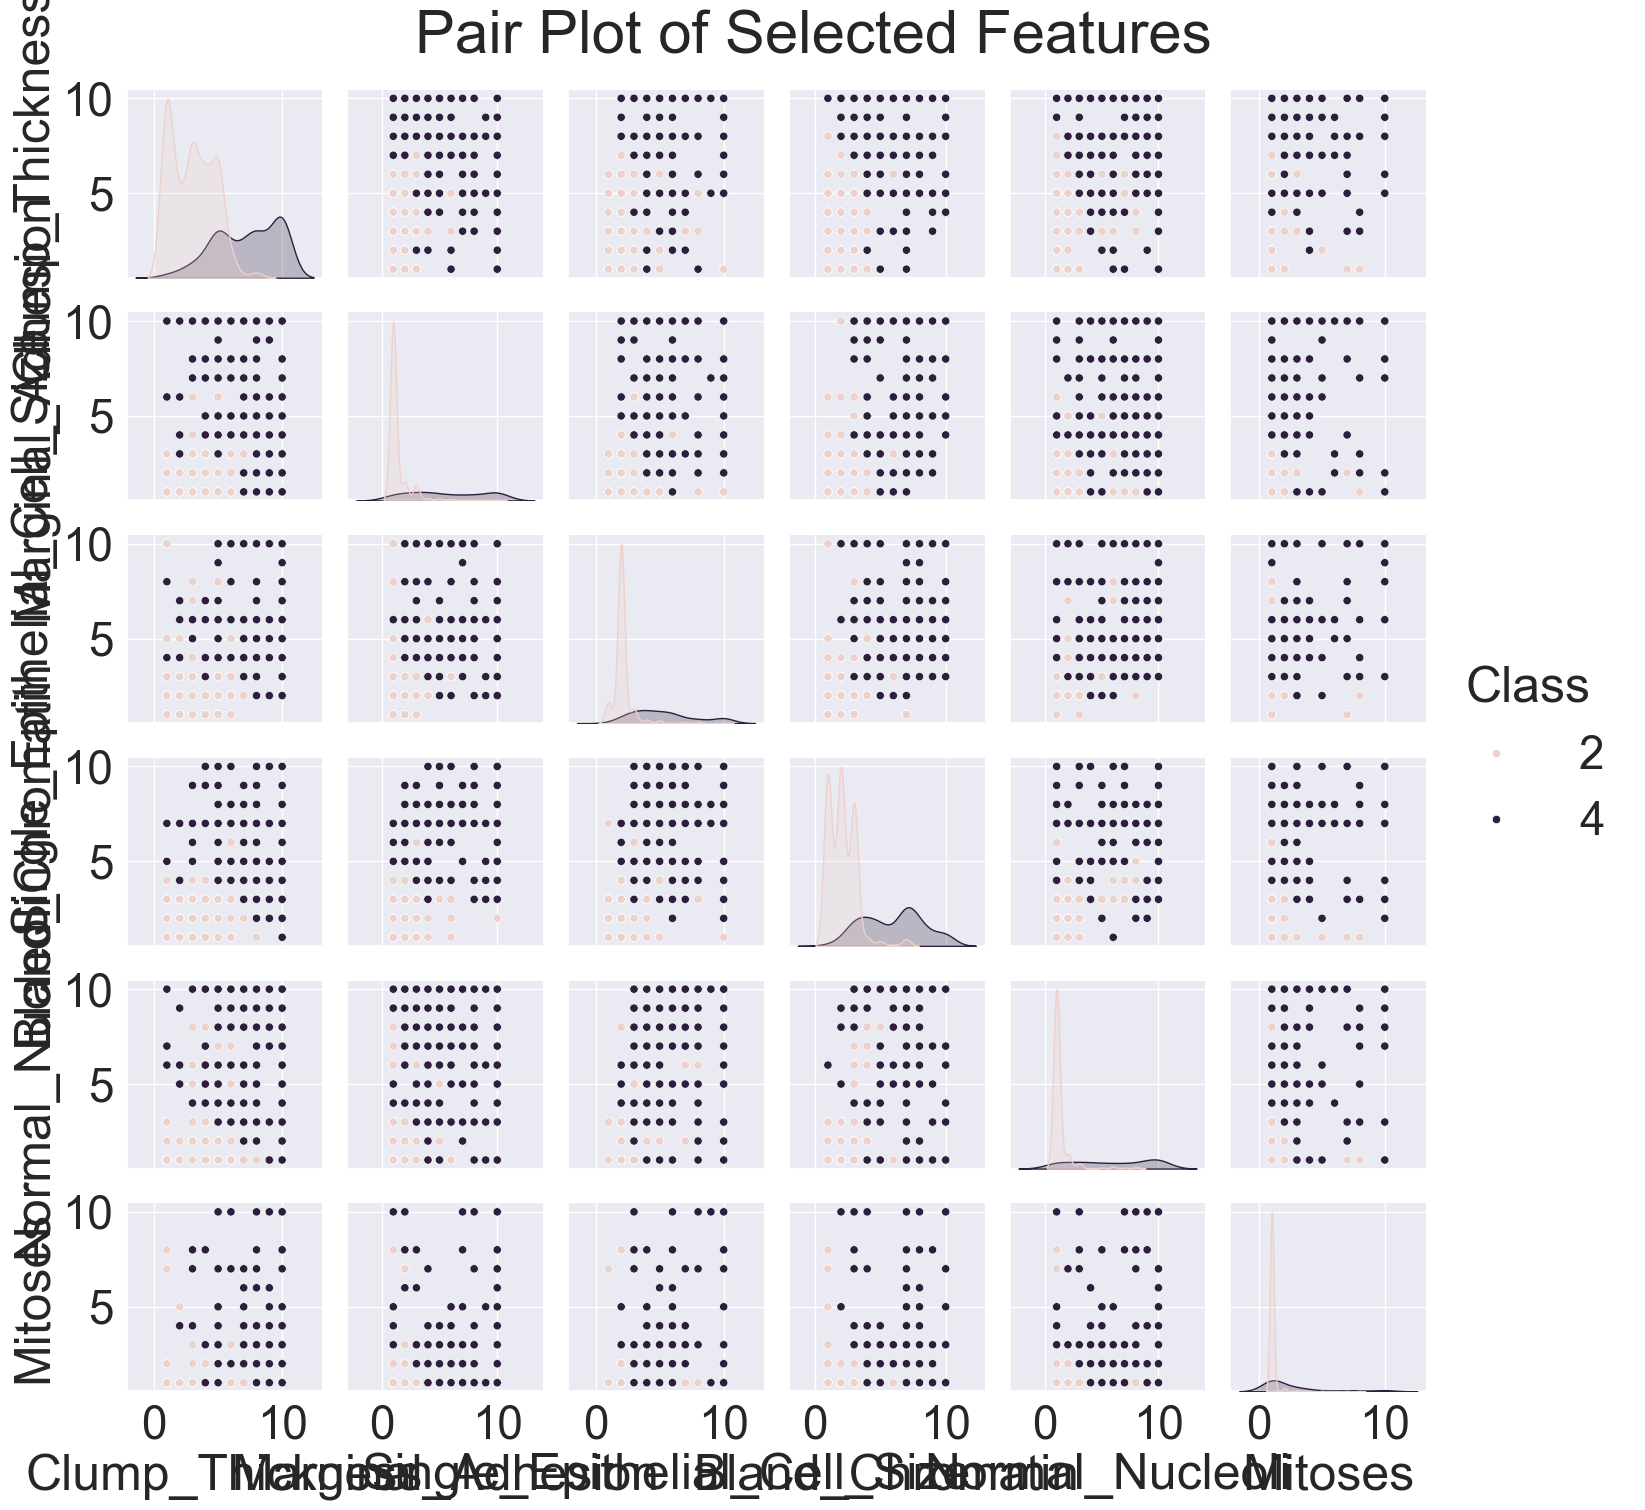

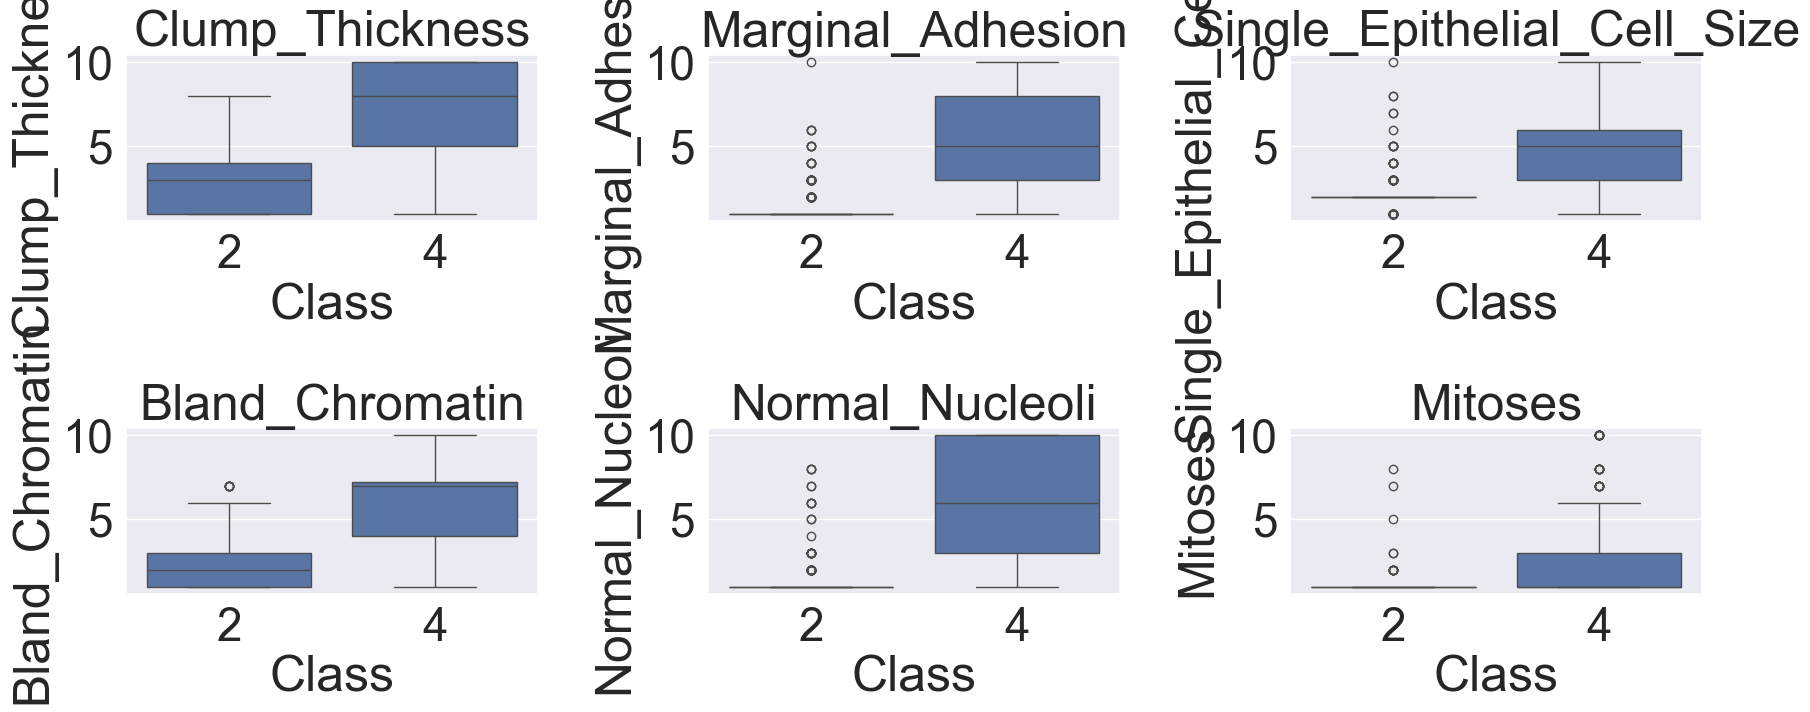

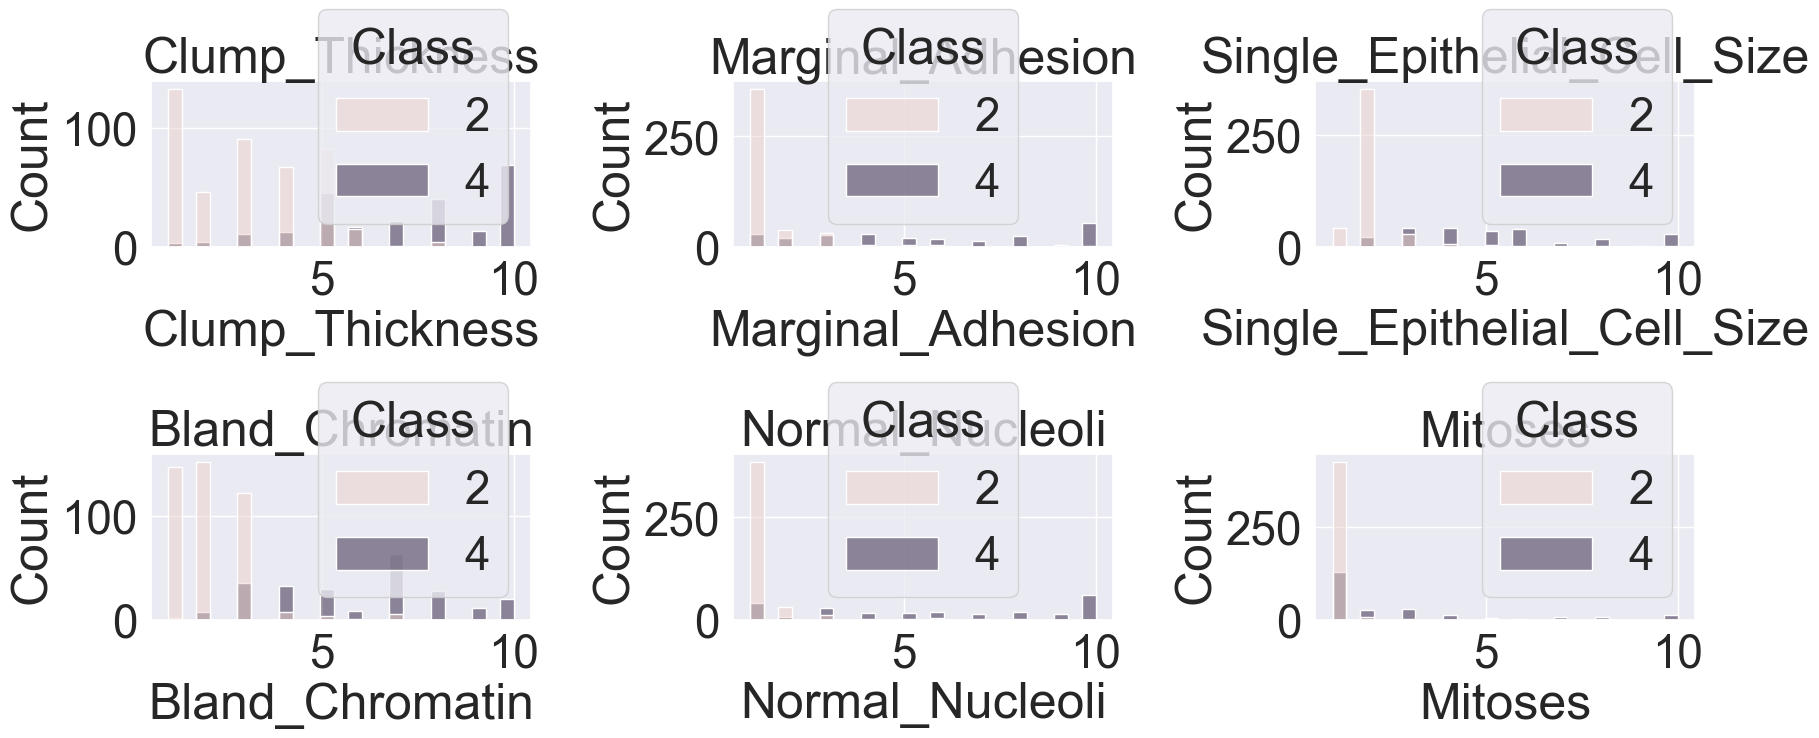

In [14]:

# ==================================================
# Pair Plot
# ==================================================

print("Generating Pair Plot...")

subset = [
   'Clump_Thickness', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size',
       'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses','Class'
]

g = sns.pairplot(
    df[subset],
    hue='Class',
    diag_kind='kde'
)

g.fig.suptitle(
    "Pair Plot of Selected Features",
    y=1.02
)



# ==================================================
# Boxplots
# ==================================================

print("Generating Boxplots...")

features = df.columns.drop("Class")

rows = (len(features)+2)//3

fig, axes = plt.subplots(
    rows,
    3,
    figsize=(18,rows*4)
)

axes = axes.flatten()

for i, feature in enumerate(features):

    sns.boxplot(
        data=df,
        x='Class',
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(feature)

# حذف المحاور الفارغة
for j in range(i+1,len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()


# ==================================================
# Histograms
# ==================================================

print("Generating Histograms...")

fig, axes = plt.subplots(
    rows,
    3,
    figsize=(18,rows*4)
)

axes = axes.flatten()

for i, feature in enumerate(features):

    sns.histplot(
        data=df,
        x=feature,
        hue='Class',
        bins=25,
        kde=False,
        ax=axes[i]
    )

    axes[i].set_title(feature)

for j in range(i+1,len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()


print("All plots generated successfully.")

#Spliting Dataset into Training and Testing Data





In [15]:
y = df['Class']
columns_to_drop = ['Class']
X = df.drop(columns=columns_to_drop)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 24)

## Importing Required Libraries

In [16]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,ConfusionMatrixDisplay, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.feature_selection import RFE, mutual_info_classif


#Trying Different Models and Checking the accuracy





Logistic Regression Model:
Accuracy: 94.08866995073892
Precision: 93.5827186512118
Recall: 93.5827186512118


<Figure size 700x300 with 0 Axes>

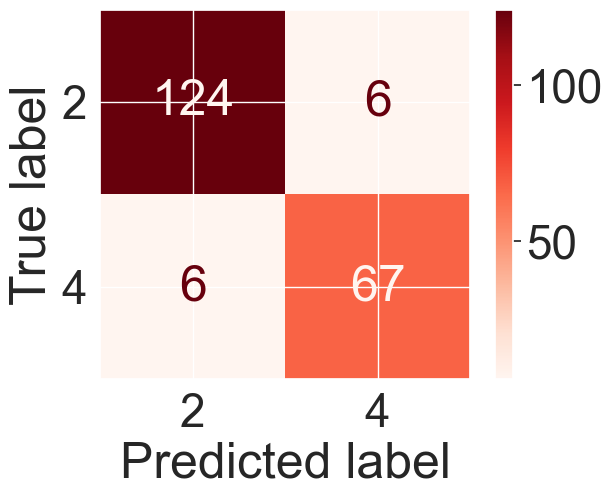

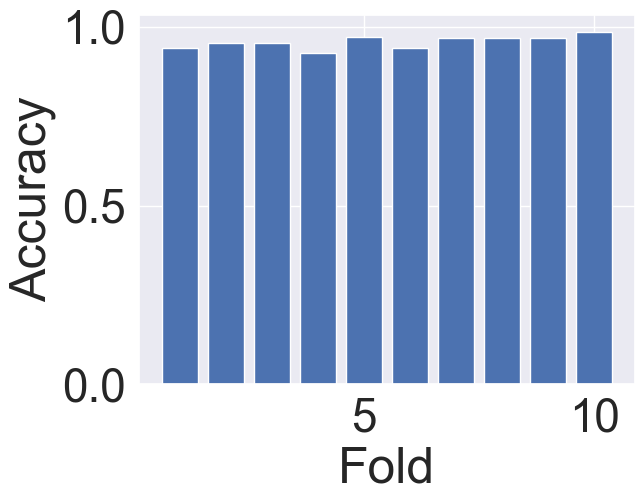

Decision Tree Classifier Model:
Accuracy: 94.08866995073892
Precision: 93.0941200489996
Recall: 94.4836670179136


<Figure size 700x300 with 0 Axes>

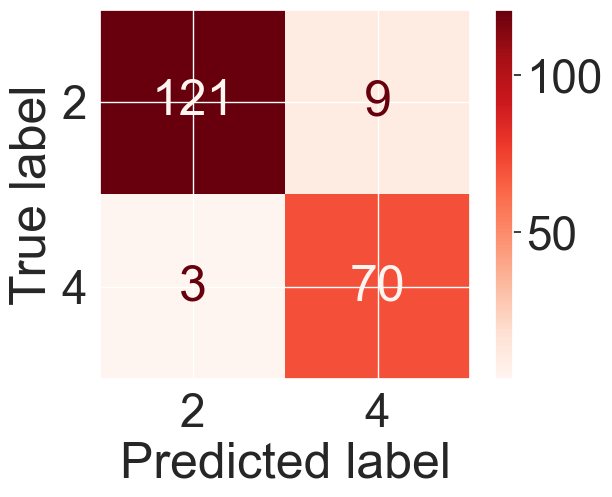

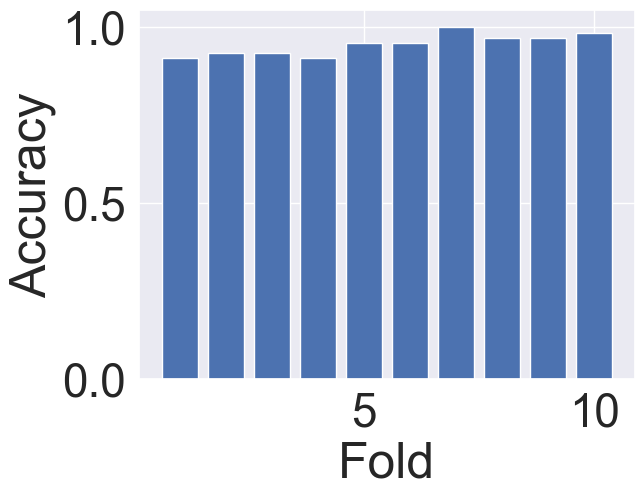

Gaussian Naive Bayes Model:
Accuracy: 94.58128078817734
Precision: 93.67179487179487
Recall: 94.86828240252898


<Figure size 700x300 with 0 Axes>

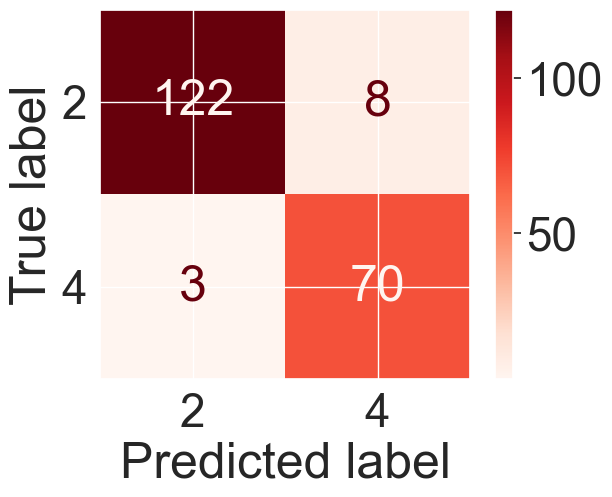

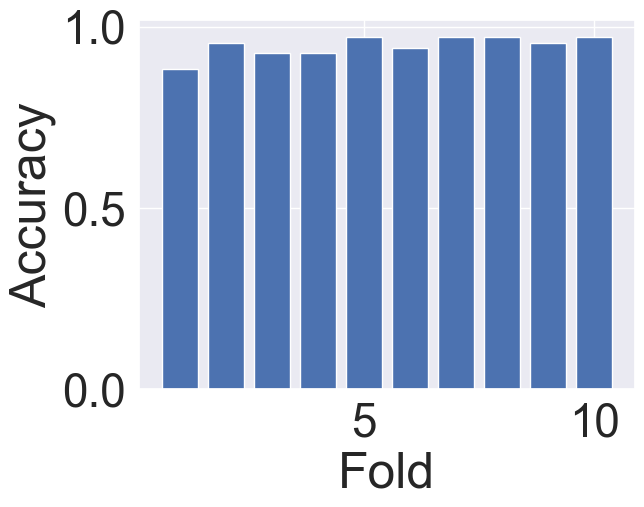

Random Forest Classifier Model:
Accuracy: 96.05911330049261
Precision: 95.3102453102453
Recall: 96.32244467860906


<Figure size 700x300 with 0 Axes>

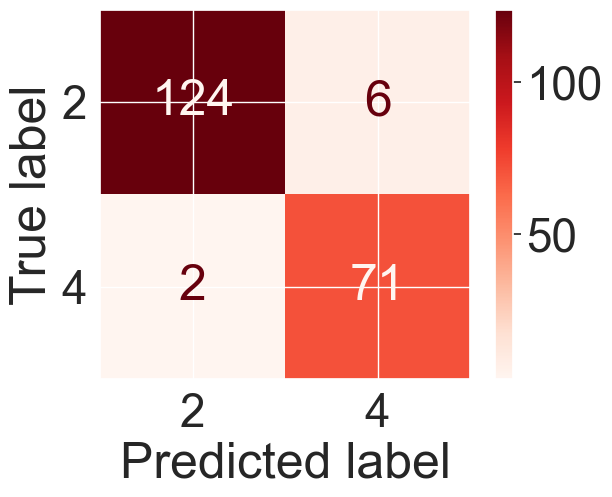

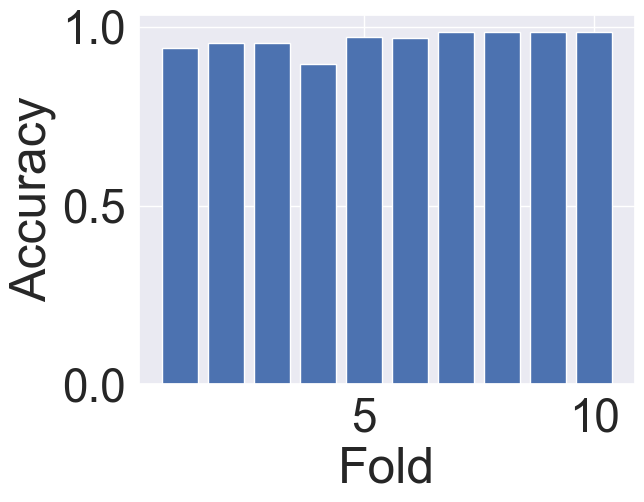

Support Vector Classifier Model:
Accuracy: 95.56650246305419
Precision: 94.7128205128205
Recall: 95.93782929399369


<Figure size 700x300 with 0 Axes>

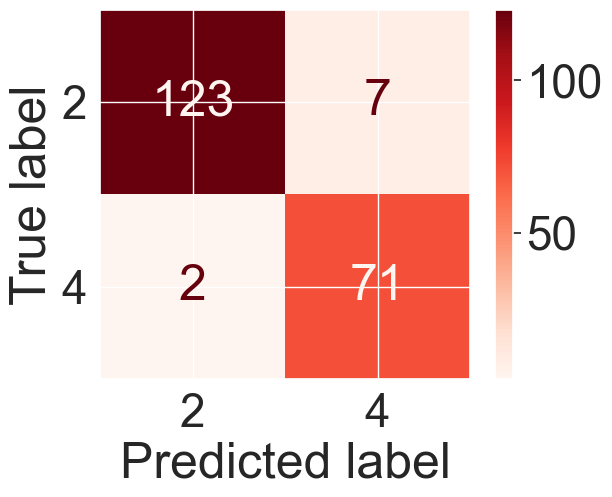

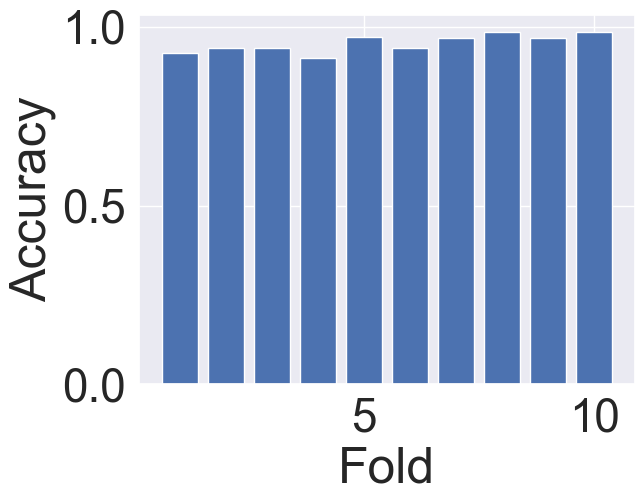

In [17]:

model1 = LogisticRegression(
    C=0.5,
    max_iter=1000,
    class_weight='balanced',
    solver='liblinear',
    random_state=42
)
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")

print("Logistic Regression Model:")
print(f"Accuracy: {accuracy*100}")
print(f"Precision: {precision*100}")
print(f"Recall: {recall*100}")

class_names = [2,4]
cm = confusion_matrix(y_test, y_pred, labels=class_names)
color = 'white'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(7,3))
disp.plot(cmap=plt.cm.Reds)
plt.show()

scores = cross_val_score(model1, X, y, cv=10)

# Plot the results of the cross-validation
plt.bar(range(1, 11), scores)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.show()
#-----------------------------------------------------------------------------------------------------------------------------------------------------
model2 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    criterion='entropy',
    class_weight='balanced',
    random_state=42
)
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")

print("Decision Tree Classifier Model:")
print(f"Accuracy: {accuracy*100}")
print(f"Precision: {precision*100}")
print(f"Recall: {recall*100}")

class_names = [2,4]
cm = confusion_matrix(y_test, y_pred, labels=class_names)
color = 'white'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(7,3))
disp.plot(cmap=plt.cm.Reds)
plt.show()

scores = cross_val_score(model2, X, y, cv=10)

# Plot the results of the cross-validation
plt.bar(range(1, 11), scores)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.show()
#-----------------------------------------------------------------------------------------------------------------------------------------------------
model3 = GaussianNB()
model3.fit(X_train, y_train)
y_pred = model3.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")

print("Gaussian Naive Bayes Model:")
print(f"Accuracy: {accuracy*100}")
print(f"Precision: {precision*100}")
print(f"Recall: {recall*100}")

class_names = [2,4]
cm = confusion_matrix(y_test, y_pred, labels=class_names)
color = 'white'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(7,3))
disp.plot(cmap=plt.cm.Reds)
plt.show()

scores = cross_val_score(model3, X, y, cv=10)

# Plot the results of the cross-validation
plt.bar(range(1, 11), scores)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.show()
#-----------------------------------------------------------------------------------------------------------------------------------------------------
model4 = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)
model4.fit(X_train, y_train)
y_pred = model4.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")

print("Random Forest Classifier Model:")
print(f"Accuracy: {accuracy*100}")
print(f"Precision: {precision*100}")
print(f"Recall: {recall*100}")

class_names = [2,4]
cm = confusion_matrix(y_test, y_pred, labels=class_names)
color = 'white'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(7,3))
disp.plot(cmap=plt.cm.Reds)
plt.show()


scores = cross_val_score(model4, X, y, cv=10)

# Plot the results of the cross-validation
plt.bar(range(1, 11), scores)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.show()
#-----------------------------------------------------------------------------------------------------------------------------------------------------
model5 = SVC(
    C=2.0,
    kernel='rbf',
    gamma='scale',
    class_weight='balanced',
    random_state=42
)
model5.fit(X_train, y_train)
y_pred = model5.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")

print("Support Vector Classifier Model:")
print(f"Accuracy: {accuracy*100}")
print(f"Precision: {precision*100}")
print(f"Recall: {recall*100}")

class_names = [2,4]
cm = confusion_matrix(y_test, y_pred, labels=class_names)
color = 'white'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(7,3))
disp.plot(cmap=plt.cm.Reds)
plt.show()

scores = cross_val_score(model5, X, y, cv=10)

# Plot the results of the cross-validation
plt.bar(range(1, 11), scores)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.show()

#Using Grid Search for hyperparameters tuning(for best model Random Forest Classifier)




In [18]:
# Tune the model's hyperparameters using grid search
param_grid = {'max_depth': [2, 5, 10, 20, 50], 'min_samples_split': [2, 5, 10, 20]}
grid_search = GridSearchCV(model4, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and the corresponding mean cross-validated score
print(f'Best hyperparameters: {grid_search.best_params_}')
print(f'Best score: {grid_search.best_score_:.2f}')


# Perform feature selection using recursive feature elimination
selector = RFE(model4, n_features_to_select=9)
selector.fit(X_train, y_train)

# Print the selected features
print(f'Selected features: {df.columns[:-1][selector.support_]}')

Best hyperparameters: {'max_depth': 5, 'min_samples_split': 5}
Best score: 0.97


C:\Users\shahed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_rfe.py:300: UserWarning: Found n_features_to_select=9 > n_features=6. There will be no feature selection and all features will be kept.
  warnings.warn(


Selected features: Index(['Clump_Thickness', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size',
       'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses'],
      dtype='str')


#Testing model





In [ ]:
# Reshape the data into a two-dimensional array
data = np.array([[1099510,10,4,3,1,3,3,6,5,2,4],
[1100524,6,10,10,2,8,10,7,3,3,4],
[1102573,5,6,5,6,10,1,3,1,1,4]])

# Create the DataFrame
new_data = pd.DataFrame(data)

y_true = new_data[10]
new_data = new_data.drop(10,axis=1)
new_data = new_data.drop(0,axis=1)

# Use the model to predict the labels for the new data
new_data_pred = model4.predict(new_data)

# Actual Label
print(f'Actual Labels: {list(y_true)}')
# Print the predictions
print(f'Predictions: {new_data_pred}')

Actual Labels: [4, 4, 4]
Predictions: [4 4 4]


In [19]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GRU, Input, Reshape
from sklearn.preprocessing import LabelEncoder


## 1. Static Neural Network (ANN)

Training Static ANN...
Static ANN Accuracy: 97.78%
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


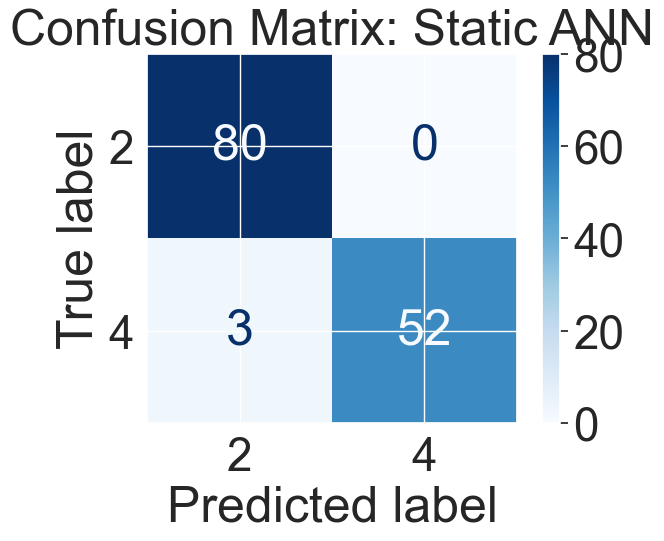

In [20]:

# --- النوع الأول: Static Neural Network (ANN/MLP) ---
# مناسبة جداً للبيانات الجدولية (Tabular Data)

# تجهيز البيانات للشبكة العصبية
le = LabelEncoder()
y_nn = le.fit_transform(y) # تحويل 2,4 إلى 0,1

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X, y_nn, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train_nn)
X_test_nn = scaler.transform(X_test_nn)

# بناء النموذج
ann_model = Sequential([
    Input(shape=(X_train_nn.shape[1],)),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training Static ANN...")
ann_model.fit(X_train_nn, y_train_nn, epochs=50, batch_size=10, verbose=0)

# التقييم
ann_loss, ann_acc = ann_model.evaluate(X_test_nn, y_test_nn, verbose=0)
print(f"Static ANN Accuracy: {ann_acc*100:.2f}%")

# مصفوفة الارتباك
y_pred_ann = (ann_model.predict(X_test_nn) > 0.5).astype("int32")
cm_ann = confusion_matrix(y_test_nn, y_pred_ann)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=le.classes_)
disp_ann.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Static ANN")
plt.show()


## 2. Dynamic Neural Network (GRU)

Training Dynamic GRU...
Dynamic GRU Accuracy: 97.78%
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


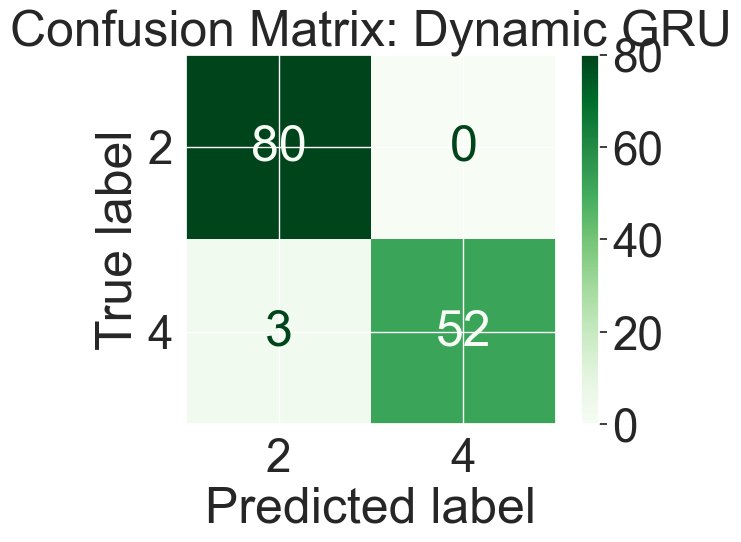

In [21]:

# --- النوع الثاني: GRU (Gated Recurrent Unit) ---
# نوع من الشبكات الديناميكية/المتكررة (RNN) وهي أكثر كفاءة من LSTM في البيانات الصغيرة

# إعادة تشكيل البيانات لتناسب GRU (Samples, Time_steps, Features)
# هنا سنعتبر الميزات الـ 8 كخطوات زمنية متتالية
X_train_gru = X_train_nn.reshape((X_train_nn.shape[0], 1, X_train_nn.shape[1]))
X_test_gru = X_test_nn.reshape((X_test_nn.shape[0], 1, X_test_nn.shape[1]))

# بناء النموذج
gru_model = Sequential([
    Input(shape=(1, X_train_nn.shape[1])),
    GRU(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training Dynamic GRU...")
gru_model.fit(X_train_gru, y_train_nn, epochs=50, batch_size=10, verbose=0)

# التقييم
gru_loss, gru_acc = gru_model.evaluate(X_test_gru, y_test_nn, verbose=0)
print(f"Dynamic GRU Accuracy: {gru_acc*100:.2f}%")

# مصفوفة الارتباك
y_pred_gru = (gru_model.predict(X_test_gru) > 0.5).astype("int32")
cm_gru = confusion_matrix(y_test_nn, y_pred_gru)
disp_gru = ConfusionMatrixDisplay(confusion_matrix=cm_gru, display_labels=le.classes_)
disp_gru.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix: Dynamic GRU")
plt.show()


#Newwwwwwwww

Training Static ANN...
Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8255 - loss: 0.5676 - val_accuracy: 0.8953 - val_loss: 0.4815
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8932 - loss: 0.4074 - val_accuracy: 0.9186 - val_loss: 0.3283
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9035 - loss: 0.2942 - val_accuracy: 0.9419 - val_loss: 0.2325
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9322 - loss: 0.2150 - val_accuracy: 0.9419 - val_loss: 0.1729
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9343 - loss: 0.1882 - val_accuracy: 0.9419 - val_loss: 0.1400
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9363 - loss: 0.1621 - val_accuracy: 0.9535 - val_loss: 0.1227
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9343 - loss: 0.1478 - val_accuracy: 0.9535 - val_loss: 0.1102
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9548 - loss: 0.1356 - val_accur

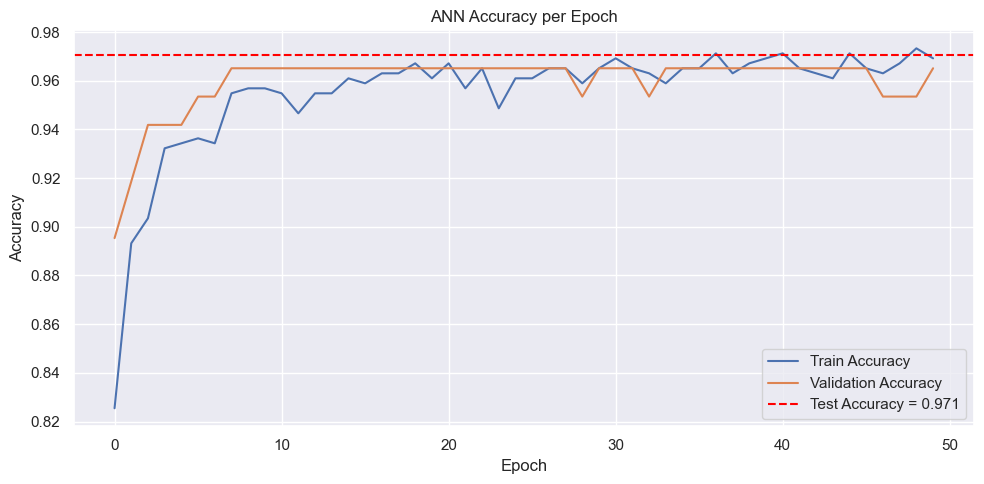

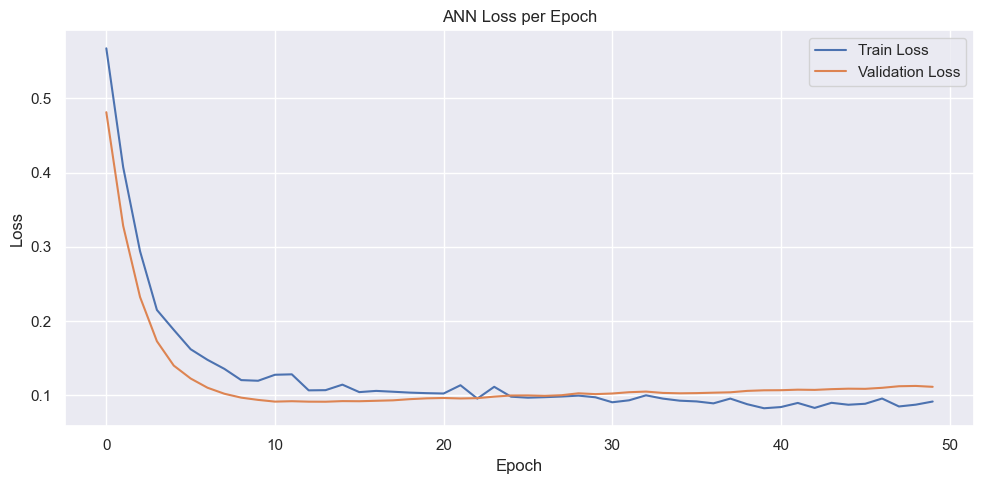

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/stepWARNING:tensorflow:6 out of the last 14 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002424D71BF60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


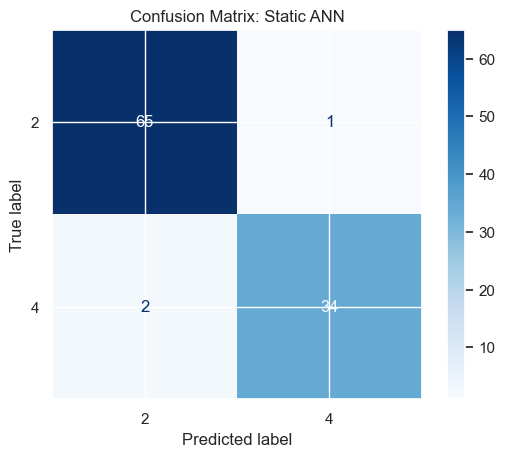

In [23]:
# --- النوع الأول: Static Neural Network (ANN/MLP) ---

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
import matplotlib.pyplot as plt

# تجهيز البيانات
le = LabelEncoder()
y_nn = le.fit_transform(y)

# أولاً: فصل Test بنسبة 15% من كامل البيانات
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X,
    y_nn,
    test_size=0.15,
    random_state=42,
    stratify=y_nn
)

# ثانياً: أخذ 15% من بيانات التدريب فقط كـ Validation
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_nn,
    y_train_nn,
    test_size=0.15,
    random_state=42,
    stratify=y_train_nn
)

# Standardization
scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train_nn)
X_val_nn = scaler.transform(X_val_nn)
X_test_nn = scaler.transform(X_test_nn)

# بناء النموذج
ann_model = Sequential([
    Input(shape=(X_train_nn.shape[1],)),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training Static ANN...")

history = ann_model.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=50,
    batch_size=10,
    verbose=1
)

# تقييم الاختبار
test_loss, test_acc = ann_model.evaluate(
    X_test_nn,
    y_test_nn,
    verbose=0
)

print(f"Test Accuracy: {test_acc*100:.2f}%")
# ==========================
# Accuracy Curve
# ==========================
# إعادة ضبط حجم الخط بعد ما تم تكبيره سابقًا بـ sns.set(font_scale=3)
sns.set(font_scale=1)
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],
         label='Train Accuracy')
plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')
# خط أفقي يمثل دقة الاختبار
plt.axhline(
    y=test_acc,
    color='red',
    linestyle='--',
    label=f'Test Accuracy = {test_acc:.3f}'
)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ANN Accuracy per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================
# Loss Curve
# ==========================
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],
         label='Train Loss')
plt.plot(history.history['val_loss'],
         label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ANN Loss per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# ==========================
# Confusion Matrix
# ==========================
y_pred_ann = (ann_model.predict(X_test_nn) > 0.5).astype(int)

cm_ann = confusion_matrix(y_test_nn, y_pred_ann)

disp_ann = ConfusionMatrixDisplay(
    confusion_matrix=cm_ann,
    display_labels=le.classes_
)

disp_ann.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Static ANN")
plt.show()



GRU Input Shape: (487, 6, 1)
Training Dynamic GRU...
Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8953 - loss: 0.5226 - val_accuracy: 0.9419 - val_loss: 0.3066
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9528 - loss: 0.1801 - val_accuracy: 0.9651 - val_loss: 0.0970
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9589 - loss: 0.1188 - val_accuracy: 0.9651 - val_loss: 0.0916
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9589 - loss: 0.1169 - val_accuracy: 0.9767 - val_loss: 0.0888
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9528 - loss: 0.1215 - val_accuracy: 0.9767 - val_loss: 0.0908
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9569 - loss: 0.1159 - val_accuracy: 0.9767 - val_loss: 0.0917
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9589 - loss: 0.1167 - val_accuracy: 0.9767 - val_loss: 0.0906
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.

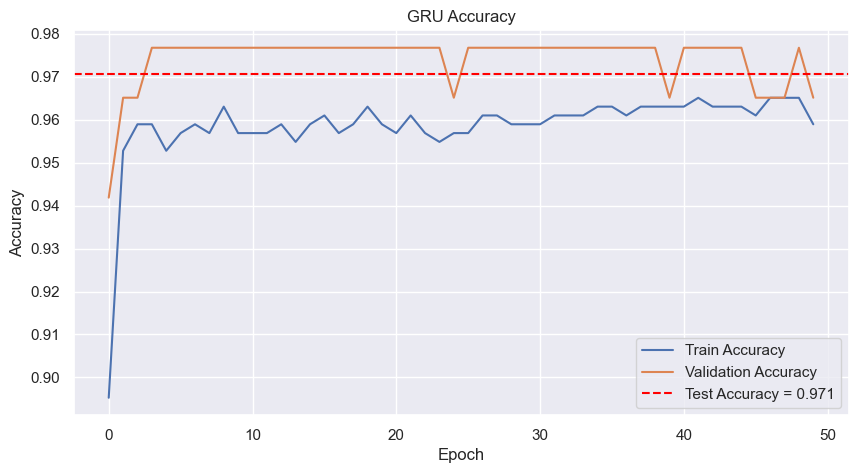

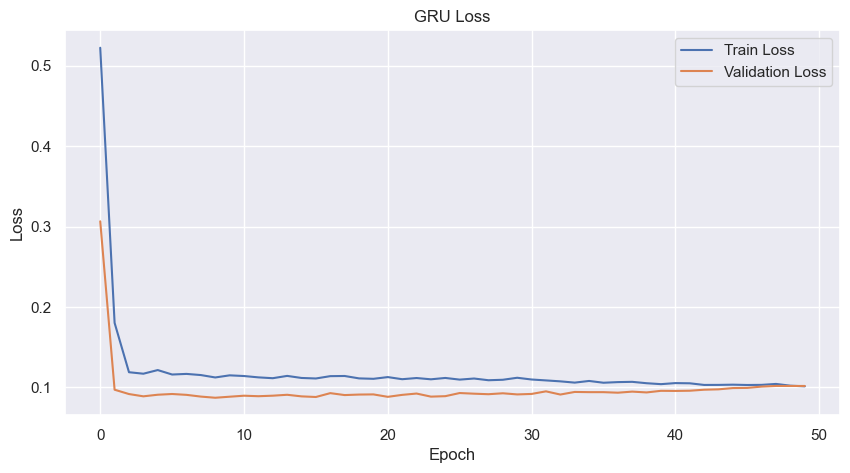

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


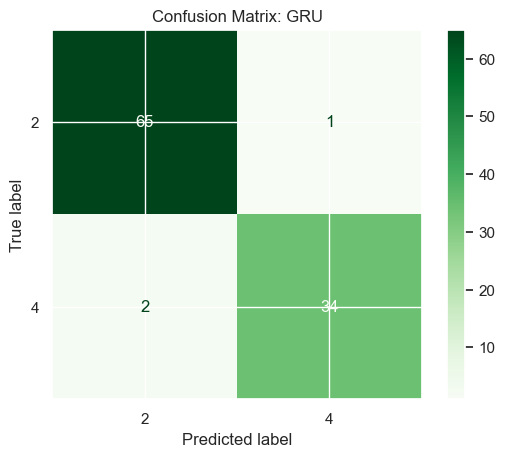

In [24]:
# --- النوع الثاني: GRU (Gated Recurrent Unit) ---

# إعادة تشكيل البيانات
# كل Feature تعتبر Time Step
X_train_gru = X_train_nn.reshape((X_train_nn.shape[0], X_train_nn.shape[1], 1))
X_val_gru   = X_val_nn.reshape((X_val_nn.shape[0], X_val_nn.shape[1], 1))
X_test_gru  = X_test_nn.reshape((X_test_nn.shape[0], X_test_nn.shape[1], 1))

print("GRU Input Shape:", X_train_gru.shape)
# (عدد العينات، عدد الخصائص، 1)

# بناء النموذج
gru_model = Sequential([
    Input(shape=(X_train_gru.shape[1], 1)),
    GRU(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training Dynamic GRU...")

history = gru_model.fit(
    X_train_gru,
    y_train_nn,
    validation_data=(X_val_gru, y_val_nn),
    epochs=50,
    batch_size=10,
    verbose=1
)

# تقييم النموذج
gru_loss, gru_acc = gru_model.evaluate(
    X_test_gru,
    y_test_nn,
    verbose=0
)

print(f"Test Accuracy: {gru_acc*100:.2f}%")
sns.set(font_scale=1)

# منحنى الدقة
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.axhline(y=gru_acc, color='red', linestyle='--',
            label=f'Test Accuracy = {gru_acc:.3f}')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# منحنى الخسارة
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Loss")
plt.legend()
plt.grid(True)
plt.show()

# مصفوفة الارتباك
y_pred_gru = (gru_model.predict(X_test_gru) > 0.5).astype(int)

cm_gru = confusion_matrix(y_test_nn, y_pred_gru)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gru,
    display_labels=le.classes_
)

disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix: GRU")
plt.show()

In [25]:
ann_model.save("breast_cancer_ann.keras")
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']